# EITN 2026 - MFM Group: Tutorial 1

In this tutorial, we will explore how the activity of a neuron can be described using mathematical models. We will first introduce the basic concepts needed to understand how neurons generate electrical activity and how this activity changes over time. We will then focus on the **E-GLIF (Extended Generalized Leaky Integrate-and-Fire)** model, an example of a computational model used to reproduce the characteristic firing behavior of different types of cerebellar neurons.

## 1. Theoretical Background

![Theoretical Background](figs/fig1.png)

## 2. Leaky Integrate and Fire (LIF) model 
A simple model for describing neuron **spiking activity** is the **Leaky Integrate-and-Fire (LIF)** model. Its main variable is the **membrane potential** of the soma V, which changes in response to incoming inputs. The neuron is modeled as an **RC circuit**: the capacitor integrates incoming currents, while the resistor accounts for the leakage toward the resting potential. When V reaches a predefined **threshold**, a **spike** is generated and V is reset.


![LIF introduction](figs/fig2.png)

In the LIF model, the **subthreshold membrane potential** \(V\) evolves according to:

$$
C \frac{dV}{dt} = -g_L(V-E_L) + I
$$

or equivalently: 

$$
\tau_m \frac{dV}{dt}=-(V-E_L) + \frac{I}{g_L}
$$

where:

- $C$ — membrane capacitance
- $g_L$ — leak conductance $\left(g_L = \frac{1}{R}\right)$
- $E_L$ — resting membrane potential
- $I$ — external input current
- $\tau_m = \frac{C_m}{g_L}$: time constant

When the membrane potential reaches a threshold $V_{th}$, a **spike** is generated and $V$ is reset to $V_{reset} < V_{th}$. The neuron then remains at $V_{reset}$ for a **refractory period** $\tau_{ref}$.

$$
V(t)=V_{reset}, \qquad
t\in[t_{sp},\,t_{sp}+\tau_{ref}]
$$

where $t_{sp}$ is the spike time.

<div style="font-size:22px; font-weight:bold; text-align:left; margin-top:20px;">
🚀 Let's simulate it!
</div>


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

In [21]:
pars = {}

# define typical nauronal parameters 
pars['V_th'] = -55.     # spike threshold [mV]
pars['V_reset'] = -75.  # reset potential [mV]
pars['tau_m'] = 10.     # membrane time constant [ms]
pars['g_L'] = 10.       # leak conductance [nS]
pars['V_init'] = -75.   # initial potential [mV]
pars['E_L'] = -75.      # leak reversal potential [mV]
pars['tref'] = 2.       # refractory time [ms] 

# simulation parameters
pars['sim_len'] = 1000.  # Total duration of simulation [ms]
pars['dt'] = .1          # Simulation time step [ms]
pars['t_steps'] = np.arange(0, pars['sim_len'], pars['dt'])  # Vector of discretized time points [ms]

In [22]:
def simulate_LIF(pars, I, stop=True):
    t = pars['t_steps'].size
    
    # Initialize voltage and current
    v = np.zeros(t)
    v[0] = pars['V_init']
    I = I * np.ones(t)

    if stop:  # set end of current to 0 if current pulse
        I[:int(len(I) / 2) - 1000] = 0
        I[int(len(I) / 2) + 1000:] = 0

    tr = 0.  # initialization of the count for refractory duration

    # Simulate the LIF dynamics
    rec_spikes = []  # array to record spike times
    for i in range(t - 1):
        if tr > 0:  # check for refractoriness
            v[i] = pars['V_reset']
            tr = tr - 1
        elif v[i] >= pars['V_th']:  # reset voltage and record spike event
            rec_spikes.append(i)
            v[i] = pars['V_reset']
            tr = pars['tref'] / pars['dt']

        # calculate the increment of the membrane potential
        dv = (-(v[i] - pars['E_L']) + I[i] / pars['g_L']) * (pars['dt'] / pars['tau_m'])

        # update the membrane potential
        v[i + 1] = v[i] + dv

    rec_spikes = np.array(rec_spikes) * pars['dt']

    return I, v, rec_spikes

In [31]:
def plot_volt_trace(pars, v, sp, I=None):
    V_th = pars['V_th']
    t_steps = pars['t_steps']

    if I is not None:
        fig, (ax1, ax2) = plt.subplots(
            2, 1, sharex=True, figsize=(8, 6),
            gridspec_kw={'height_ratios': [3, 1]}
        )
    else:
        fig, ax1 = plt.subplots(figsize=(8, 4))

    ax1.set_title('Membrane Potential')
    ax1.plot(t_steps, v, 'r')
    ax1.axhline(V_th, 0, 1, color='gray', ls='--')

    if len(sp) > 0:
        ax1.vlines(sp, V_th+1, V_th + 4, color='g', lw=2, label='Spike')

    ax1.set_ylabel('V [mV]')
    ax1.set_ylim([-80, -40])
    ax1.legend(['Membrane\npotential', r'Threshold V$_{\mathrm{th}}$', 'Spike'],
               loc=[1.05, 0.75])

    if I is not None:
        ax2.set_title('Injected current')
        ax2.plot(t_steps, I, 'b')
        ax2.set_xlabel('Time [ms]')
        ax2.set_ylabel('I [pA]')
        ax2.set_ylim([I.min() - 5, I.max() + 5])
    else:
        ax1.set_xlabel('Time [ms]')

    plt.tight_layout()

### 2.1 Subthreshold dynamics
A simple example of the response to a constant current step, without spike generation. We can observe the charging of the membrane during the input and its subsequent decay toward the resting potential due to membrane leakage.

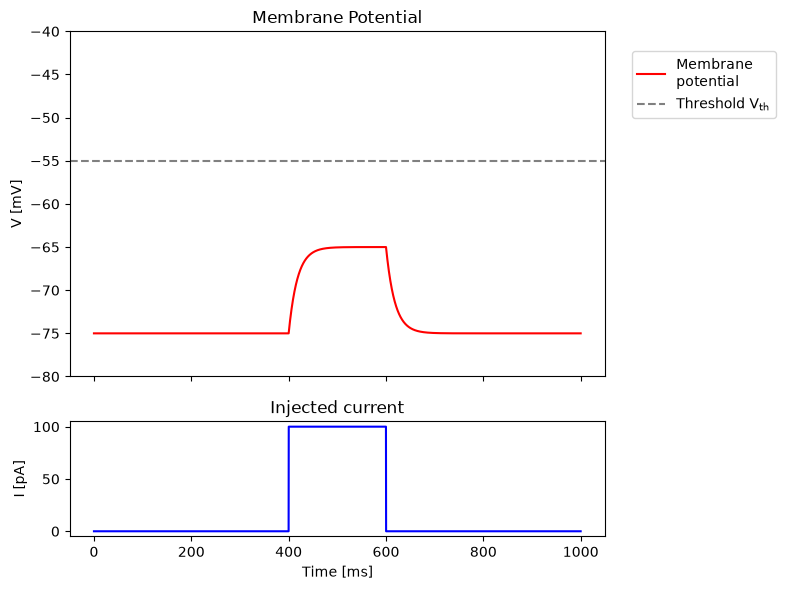

In [32]:
I_t, v, sp = simulate_LIF(pars, I=100, stop=True)
plot_volt_trace(pars, v, sp, I = I_t)
plt.show()

### 2.2 LIF neuron + DC current step
In this section, we will explore how a constant input current affects the activity of an LIF neuron. In particular, we will investigate:

- How much current is required for the neuron to reach threshold and start firing?
- How does the membrane time constant affect the neuron's spiking frequency?

In [35]:
def DC_input(I=200., tau_m=10.):
    pars['tau_m'] = tau_m
    I_t, v, sp = simulate_LIF(pars, I=I,stop=True)
    plot_volt_trace(pars, v, sp)
    plt.show()

In [36]:
_ = widgets.interact(DC_input, I= (0.,300,10), tau_m = (2,20,2))

interactive(children=(FloatSlider(value=200.0, description='I', max=300.0, step=10.0), IntSlider(value=10, des…

## 3. Extendend Generalized Leak Integrated and Fire (EGLIF) model
We need a more complex model to reproduce a broader range of electroresponsive properties than a simple LIF model, including autorhythmicity, rebound firing, bursting, and spike-frequency adaptation.

![Examples_electroresponsive_properties](figs/fig3.png) 

The model consists of a set of 3 differential equations describing the time evolution of:

1) **Membrane Potential** ($V$)
2) **Adaptation Current** ($I_{adap}$): reproduces the activation of potassium channels, generating a slow hyperpolarizing current
3) **Depolarization Current** ($I_{dep}$): acts as a spike-triggered depolarizing current, mimicking the fast activation of sodium channels


<div style="font-size:22px; font-weight:bold; text-align:left; margin-top:20px;">
Model equations
</div>

The E-GLIF model is described by a system of 3 coupled linear ordinary differential equations:

$$
\begin{cases}
\dfrac{dV_m(t)}{dt} = \dfrac{1}{C_m}\left(\dfrac{C_m}{\tau_m}\big(V_m(t)-E_L\big) - I_{adap}(t) + I_{dep}(t) + I_e + I_{stim}\right) \\[8pt]
\dfrac{dI_{adap}(t)}{dt} = k_{adap}\big(V_m(t)-E_L\big) - k_2 \cdot I_{adap}(t) \\[8pt]
\dfrac{dI_{dep}(t)}{dt} = -k_1 \cdot I_{dep}(t)
\end{cases}
$$

where:
- $I_{stim}$ = external stimulation current
- $C_m$ = membrane capacitance
- $\tau_m$ = membrane time constant
- $E_L$ = resting potential
- $I_e$ = endogenous current (accounts for autorhythmicity)
- $k_{adap}, k_2$ = adaptation constants
- $k_1$ = $I_{dep}$ decay rate

**Spike generation:** if the neuron is not in the refractory period $\tau_{ref}$, a spike is generated at time $t_{spk}$.

**Update rules (post-spike reset):**

$$
\begin{cases}
V_m(t_{spk}^+) = V_r \\
I_{adap}(t_{spk}^+) = I_{adap}(t_{spk}) + A_2 \\
I_{dep}(t_{spk}^+) = A_1
\end{cases}
$$

where $V_r$ is the reset potential, and $A_1$, $A_2$ are the model currents' update (step) constants applied after each spike.

- **Fixed parameters** (directly measured neurophysiological quantities): $C_m, \tau_m, E_L, \tau_{ref}, V_{th}, V_r$.
- **Tunable parameters** (optimized for each specific cell type): $k_{adap}, k_2, k_1, A_1, A_2, I_e$.